이미지 분석 및 스티커 합성을 시작합니다...
C:/Users/Owner/aiffel/workplace/camera_sticker/images/front.jpg: Sticker Applied
C:/Users/Owner/aiffel/workplace/camera_sticker/images/side.jpg: Sticker Applied
C:/Users/Owner/aiffel/workplace/camera_sticker/images/up.jpg: Sticker Applied
C:/Users/Owner/aiffel/workplace/camera_sticker/images/down.jpg: Sticker Applied
C:/Users/Owner/aiffel/workplace/camera_sticker/images/far.jpg: Sticker Applied
결과를 출력합니다.


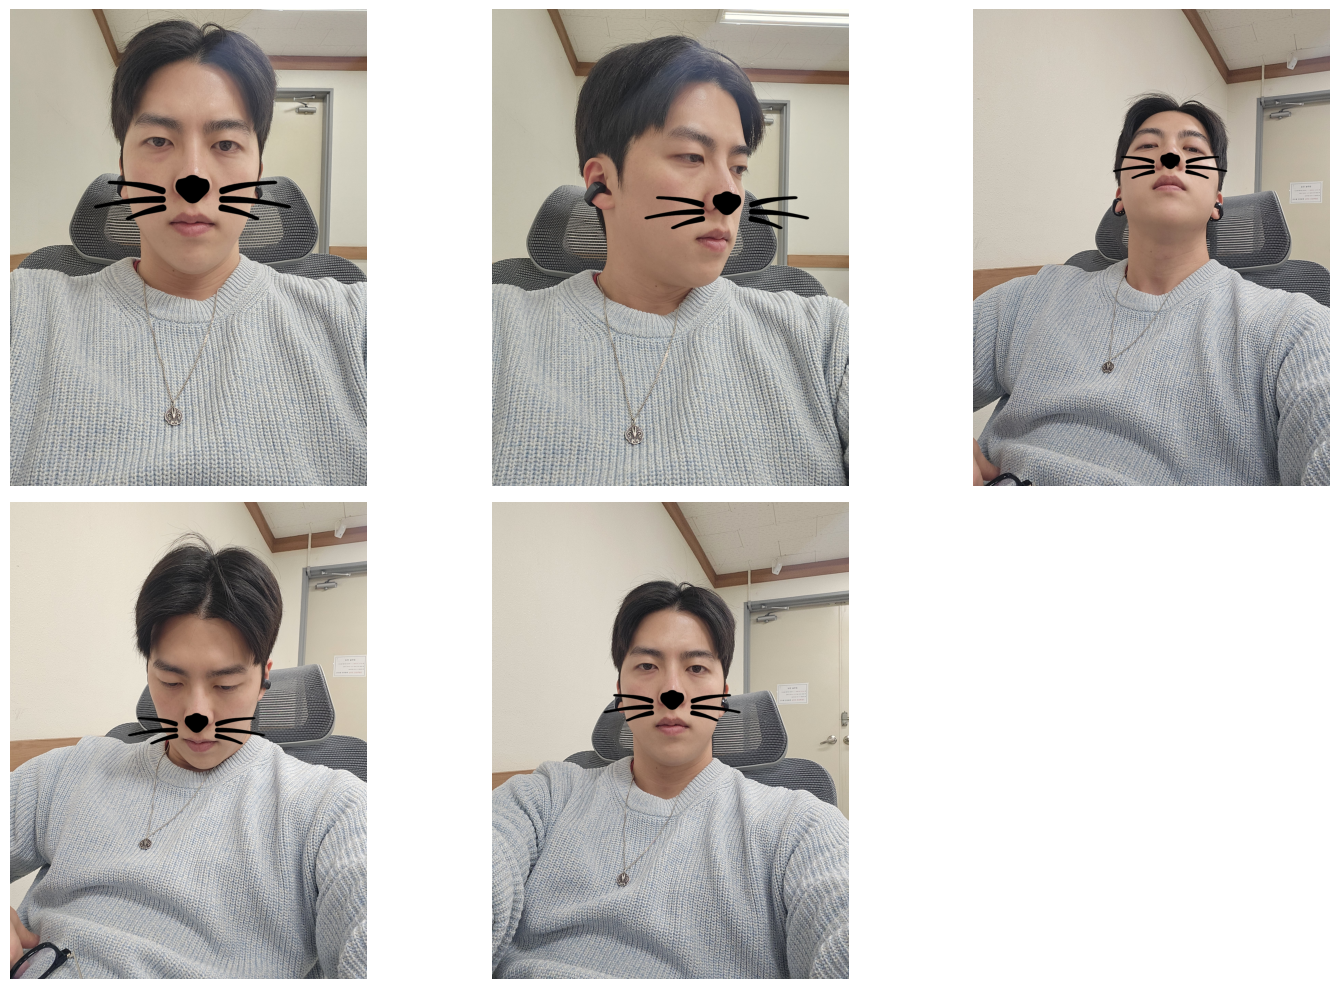

In [1]:
import cv2
import dlib
import matplotlib.pyplot as plt
import os

detector = dlib.get_frontal_face_detector()
predictor_path = "C:/Users/Owner/aiffel/workplace/camera_sticker/models/shape_predictor_68_face_landmarks.dat"
sticker_path = "C:/Users/Owner/aiffel/workplace/camera_sticker/images/cat-whiskers.png" # 고양이 수염 이미지 파일명

# 파일 존재 여부 확인
if not os.path.exists(predictor_path):
    print(f"오류: '{predictor_path}' 모델 파일이 필요합니다.")
    exit()
if not os.path.exists(sticker_path):
    print(f"오류: '{sticker_path}' 스티커 이미지 파일이 필요합니다. 경로를 확인해주세요.")
    exit()

predictor = dlib.shape_predictor(predictor_path)

# 스티커 이미지 로드 (알파 채널 포함 필수!)
# cv2.IMREAD_UNCHANGED 옵션이 중요합니다.
img_sticker_orig = cv2.imread(sticker_path, cv2.IMREAD_UNCHANGED)
if img_sticker_orig is None or img_sticker_orig.shape[2] != 4:
    print("오류: 스티커 이미지를 로드할 수 없거나 알파 채널(투명도)이 없습니다.")
    exit()

# 이미지 파일 목록
image_files = [
    "C:/Users/Owner/aiffel/workplace/camera_sticker/images/front.jpg", # 정면 (기준)
    "C:/Users/Owner/aiffel/workplace/camera_sticker/images/side.jpg", # 우측 측면
    "C:/Users/Owner/aiffel/workplace/camera_sticker/images/up.jpg", # 아래에서 위로 (로우 앵글)
    "C:/Users/Owner/aiffel/workplace/camera_sticker/images/down.jpg", # 위에서 아래로 (하이 앵글)
    "C:/Users/Owner/aiffel/workplace/camera_sticker/images/far.jpg", # 카메라에서 먼 거리 정면]
]

# --- 헬퍼 함수: 투명 이미지를 배경에 합성 ---
def overlay_transparent(background_img, img_to_overlay_t, x, y, overlay_size=None):
    bg_img = background_img.copy()

    # 스티커 크기 조절
    if overlay_size is not None:
        img_to_overlay_t = cv2.resize(img_to_overlay_t.copy(), overlay_size)

    # 기본 정보 추출
    b, g, r, a = cv2.split(img_to_overlay_t)
    overlay_color = cv2.merge((b, g, r))

    # 1. 좌표 계산 및 경계 벗어남 처리 (Clipping)
    h, w, _ = overlay_color.shape
    roi_x, roi_y = x, y

    # 음수 좌표 처리 (이미지 왼쪽/위로 나간 경우)
    x_start = 0; y_start = 0
    if roi_x < 0:
        x_start = -roi_x
        roi_x = 0
    if roi_y < 0:
        y_start = -roi_y
        roi_y = 0

    # 이미지 오른쪽/아래로 나간 경우 처리
    x_end = w; y_end = h
    if roi_x + (x_end - x_start) > bg_img.shape[1]:
        x_end = bg_img.shape[1] - roi_x + x_start
    if roi_y + (y_end - y_start) > bg_img.shape[0]:
        y_end = bg_img.shape[0] - roi_y + y_start

    # 잘라낸 영역(ROI)이 유효하지 않으면 원본 반환
    if x_end - x_start <= 0 or y_end - y_start <= 0:
        return bg_img

    # 2. 실제 합성할 영역 추출
    sticker_roi = overlay_color[y_start:y_end, x_start:x_end]
    alpha_roi = a[y_start:y_end, x_start:x_end] / 255.0 # 0.0 ~ 1.0으로 정규화
    bg_roi = bg_img[roi_y:roi_y+(y_end-y_start), roi_x:roi_x+(x_end-x_start)]

    # 3. 알파 블렌딩 (핵심 공식)
    # 결과 = (스티커색 * 알파) + (배경색 * (1 - 알파))
    for c in range(0, 3): # BGR 채널 반복
        bg_roi[:, :, c] = (alpha_roi * sticker_roi[:, :, c] +
                           (1.0 - alpha_roi) * bg_roi[:, :, c])

    return bg_img

# --- 메인 처리 루프 ---
processed_images = []
titles = []

print("이미지 분석 및 스티커 합성을 시작합니다...")

for file_name in image_files:
    if not os.path.exists(file_name): continue

    img_bgr = cv2.imread(file_name)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_show = img_rgb.copy()

    faces = detector(img_rgb, 1)
    status = "Face Not Found"

    if len(faces) > 0:
        face = faces[0]
        status = "Sticker Applied"
        shape = predictor(img_rgb, face)

        # --- 스티커 위치 및 크기 계산 ---

        # 1. 기준점 선정: 코의 중심 (dlib 33번 인덱스)
        nose_center = shape.part(33)
        center_x, center_y = nose_center.x, nose_center.y

        # 2. 스티커 크기 결정: 얼굴 너비의 1.2배 정도로 설정
        face_width = face.width()
        scaler = 1.2
        sticker_w = int(face_width * scaler)
        # 원본 비율 유지하며 높이 계산
        ratio = sticker_w / img_sticker_orig.shape[1]
        sticker_h = int(img_sticker_orig.shape[0] * ratio)

        # 3. 스티커 좌측 상단 좌표 계산 (기준점에서 스티커 절반 크기만큼 이동)
        top_left_x = center_x - sticker_w // 2
        top_left_y = center_y - sticker_h // 2

        # 4. 합성 함수 호출
        img_show = overlay_transparent(
            img_show, img_sticker_orig,
            top_left_x, top_left_y,
            (sticker_w, sticker_h)
        )

        # (선택사항) 랜드마크 기준점 확인용 붉은 점 표시
        # cv2.circle(img_show, (center_x, center_y), 5, (255, 0, 0), -1)

    processed_images.append(img_show)
    titles.append(f"{file_name}\n({status})")
    print(f"{file_name}: {status}")


# --- 결과 시각화 ---
print("결과를 출력합니다.")
plt.figure(figsize=(15, 10))
rows, cols = 2, 3
for i, img in enumerate(processed_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')
plt.tight_layout()

plt.show()